In [63]:
import pandas as pd

df = pd.read_csv('../datasets/redmi6.csv', encoding='windows-1252')

In [64]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
120,Love this product,Deepak kumar,5.0 out of 5 stars,on 18 September 2018,Others,Wonderful phone.....,NaN
164,Value for money very good,MOHD AARISH,5.0 out of 5 stars,on 23 September 2018,Others,Very good product,NaN
55,Quality is not good,Vamshi Vadikari,1.0 out of 5 stars,on 27 September 2018,Others,Worst phone from MI and Amazon\nTouch was not ...,One person found this helpful
38,Good phone in budget,Amazon Customer,4.0 out of 5 stars,on 1 October 2018,Battery,"Good phone in budget. Good camera,battery and ...",
206,Good,Raj kumar,5.0 out of 5 stars,on 20 September 2018,Others,Good,NaN
24,Thanks alot Amazon,sonu,5.0 out of 5 stars,on 24 September 2018,Battery,"Thanks alot Amazon,ecom & seller.perfect produ...",One person found this helpful
167,Excellent,????? ?????,5.0 out of 5 stars,on 19 September 2018,Others,Excellent,NaN
211,Joordaar maja aaa gya,Joginder Singh ahuja,5.0 out of 5 stars,on 19 September 2018,Others,Nice,NaN
116,Good,Darshan V,5.0 out of 5 stars,on 27 September 2018,Others,Good,NaN
82,Smart brand.,Amazon Customer,5.0 out of 5 stars,on 24 September 2018,Display,Display is best.,NaN


In [65]:
df.isnull().sum()

# We don't use 'Useful' column, so no problem with missing values

Review Title       0
Customer name      0
Rating             0
Date               0
Category           0
Comments           0
Useful           170
dtype: int64

In [66]:
df['Rating'] = df['Rating'].str.split(' ', expand=True)[0]

In [67]:
df['Rating'].unique().tolist()

['4.0', '3.0', '5.0', '2.0', '1.0']

In [68]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
146,Battery life,Aman Rana,4.0,on 25 September 2018,Others,Phone system is nice,NaN
97,Not A camera fone,Amazon Customer,4.0,on 29 September 2018,Camera,Looking wise sexy but camera quality is not wo...,NaN
230,A compact power pack Device with great battery...,kunal Sethi,5.0,on 20 September 2018,Display,This device feels great in hand because it is ...,NaN
218,Worst front camera on a Mi device till date.,Ram Rajkishore,1.0,on 15 September 2018,Camera,It has a worst front camera I have ever seen o...,NaN
254,I am satisfying this phone,Jit saha,5.0,on 28 September 2018,Others,Bettary so good,NaN
273,Dont Buy,Sameet S.,1.0,on 19 September 2018,Battery,Charging issue\nLagging issue\nhanging issue\n...,NaN
135,I've fallen in love!,Aahil Asad Ahmad,5.0,on 24 September 2018,Others,I've fallen in love!,NaN
118,Sound v acha nhi hai,Md shahab,4.0,on 23 September 2018,Camera,Front camera low hai cost jyada hair 9999 take...,NaN
100,Ek jakas cellphone,Amazon Customer,5.0,on 22 September 2018,Others,"This cellphone is good & economical , more fea...",NaN
14,Not worth for the money,Sudhakaran Wadakkancheri,2.0,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful


In [69]:
df = df[['Rating', 'Comments', 'Category']]

In [70]:
# Check for missing values

df.isnull().sum()

Rating      0
Comments    0
Category    0
dtype: int64

In [71]:
df.sample(10)

,Rating,Comments,Category
96,3.0,Sound qulity not dolby and processor performan...,Others
107,5.0,Best notch light weight phon.,Others
102,5.0,Display Quality and battery backup is good,Display
154,4.0,Nice,Others
177,5.0,Really like it,Others
73,4.0,Mobile is good also service of Amazon is bette...,Others
207,5.0,Nice,Others
200,5.0,Good,Others
188,5.0,super,Others
15,3.0,Over prised by at least around Rs.1000/- Low l...,Display


In [72]:
df.count()

Rating      280
Comments    280
Category    280
dtype: int64

In [73]:
# This code is used to categorize comments into different sentiment categories using the Ollama API (with qwen2.5-coder:latest model).

import ollama


for i in range(len(df['Comments'])):
    comment = df['Comments'].iloc[i]

    response = ollama.generate(
        model='qwen2.5-coder:latest',  
        prompt=f"Categorize {comment}, make you return only: Very Negative, Negative, Neutral, Positive, Very Positive, without any explanation."
    )

    try:
        result = response['response'].strip()
        comment_category = 'Unknown'
        if result in ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']:
            comment_category = result
        else:
            comment_category = 'Unknown'
    except KeyError as e:
        print(f"KeyError: {e}") 

    df.loc[i, 'Comment Categories'] = comment_category
    print(f"i: {i}, comment category: {comment_category}")

i: 0, comment category: Positive
i: 1, comment category: Negative
i: 2, comment category: Positive
i: 3, comment category: Positive
i: 4, comment category: Very Negative
i: 5, comment category: Positive
i: 6, comment category: Positive
i: 7, comment category: Negative
i: 8, comment category: Neutral
i: 9, comment category: Negative
i: 10, comment category: Positive
i: 11, comment category: Negative
i: 12, comment category: Positive
i: 13, comment category: Positive
i: 14, comment category: Negative
i: 15, comment category: Positive
i: 16, comment category: Positive
i: 17, comment category: Negative
i: 18, comment category: Neutral
i: 19, comment category: Very Negative
i: 20, comment category: Positive
i: 21, comment category: Positive
i: 22, comment category: Negative
i: 23, comment category: Negative
i: 24, comment category: Positive
i: 25, comment category: Unknown
i: 26, comment category: Negative
i: 27, comment category: Negative
i: 28, comment category: Positive
i: 29, comment ca

In [74]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
dtype: int64

In [75]:
df['Comment Categories'].unique().tolist()

['Positive',
 'Negative',
 'Very Negative',
 'Neutral',
 'Unknown',
 'Very Positive']

In [76]:
# Only load data that Comment Category equals to 'Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive', avoid 'Unknown' 
df = df[df['Comment Categories'].isin(['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])]

In [77]:
df['Comment Categories'].unique().tolist()

['Positive', 'Negative', 'Very Negative', 'Neutral', 'Very Positive']

In [78]:
df.count()

Rating                277
Comments              277
Category              277
Comment Categories    277
dtype: int64

In [80]:
# Change data type
df.loc[:,'Rating'] = df['Rating'].astype(float)

In [81]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating'].map({5.0: 'Very Positive', 4.0: 'Positive', 3.0: 'Neutral', 2.0: 'Negative', 1.0: 'Very Negative'}) 

In [82]:
df.sample(10)

,Rating,Comments,Category,Comment Categories,Rating Categories
128,4.0,Nice mobile in this price range,Others,Negative,Positive
99,5.0,"This cellphone is good & economical , more fea...",Others,Positive,Very Positive
23,1.0,Please don't buy these product.. I have 3-mobi...,Others,Negative,Very Negative
174,5.0,Perfect,Others,Negative,Very Positive
273,1.0,Charging issue\nLagging issue\nhanging issue\n...,Battery,Negative,Very Negative
198,5.0,Its osm,Others,Negative,Very Positive
191,5.0,Nice mobile,Others,Positive,Very Positive
253,5.0,"Very nice looking, slim, light weight, sound q...",Battery,Positive,Very Positive
1,3.0,All ok but vry small size mobile,Others,Negative,Neutral
119,4.0,Overall the product build and handling quality...,Others,Positive,Positive


In [83]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [84]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

               Rating Categories Count  Comment Categories Count
Very Positive                      149                         9
Positive                            50                       155
Very Negative                       42                        19
Neutral                             27                        25
Negative                             9                        69


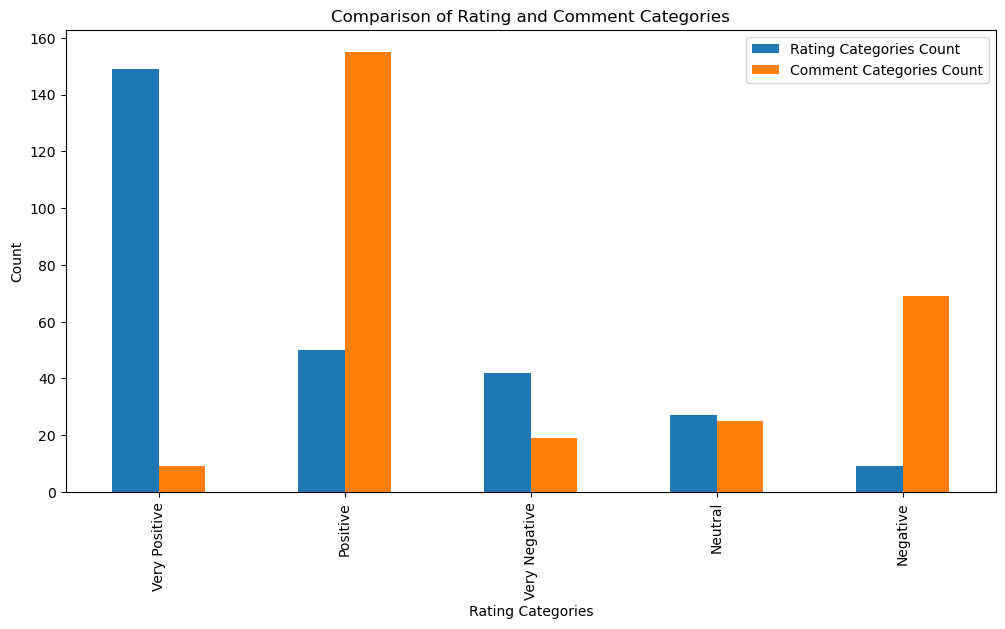

In [85]:
import matplotlib.pyplot as plt

# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

In [86]:
# Get the mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 216


In [87]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

In [88]:
# Do mapping Comment Categories
df.loc[:, 'Comment Categories'] = df['Comment Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'})

In [89]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [90]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

          Rating Categories Count  Comment Categories Count
Positive                      199                       164
Negative                       51                        88
Neutral                        27                        25


In [91]:
# Get mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 76


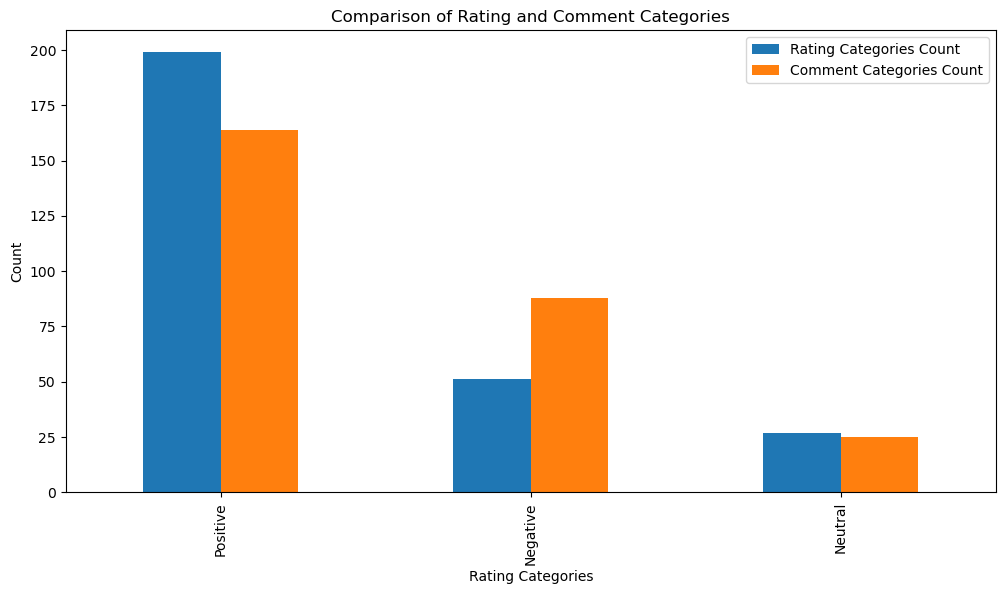

In [92]:
# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

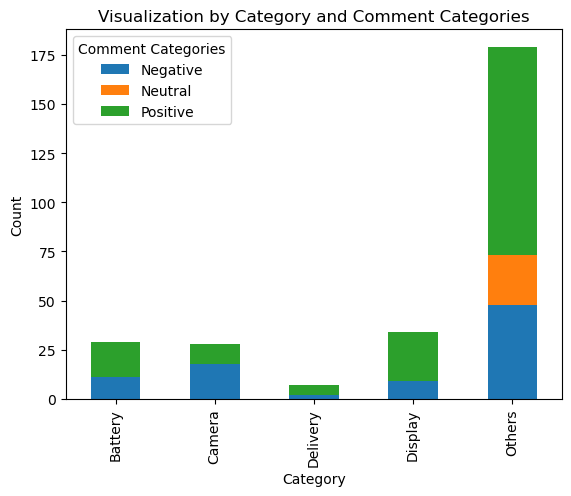

In [93]:
# Create pivot table
pivot_table = df.pivot_table(index='Category', columns='Comment Categories', aggfunc='size', fill_value=0)

# Display the pivot table
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Visualization by Category and Comment Categories')
plt.show()